In [ ]:
import json
import pandas
import requests

# url = "https://festim.discourse.group/categories.json?include_subcategories=false"
# url = "https://festim.discourse.group/t/{id}.json"
# id = "interface-condition-issue-in-multi-material-diffusion-with-mixed-solubility-laws"
# url = url.format(id=id)

url = "https://festim.discourse.group/admin/reports/consolidated_page_views.json"
# request is: GET https://{defaultHost}/t/{id}.json
API_KEY = "266410ba3867eca0324d3c8324ad3c2fea36b7799a905237805759d1953b4c08"

# set start and end date for the report (last 3 months)
import datetime

end_date = datetime.datetime.now()
start_date = datetime.datetime(2022, 1, 1)

url += f"?start_date={start_date}&end_date={end_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response_data = json.loads(response.text)

# dump file
with open("discourse_response.json", "w") as f:
    json.dump(response_data, f, indent=4)


In [2]:
# print(response_data)
data = pandas.DataFrame(response_data["report"]["data"])

data

,req,label,color,data
0,page_view_logged_in,Logged in users,#1EB8D1,"[{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-..."
1,page_view_anon,Anonymous users,#9BC53D,"[{'x': '2023-11-23', 'y': 9}, {'x': '2023-11-2..."
2,page_view_crawler,Crawlers,#721D8D,"[{'x': '2023-11-24', 'y': 2}, {'x': '2023-11-2..."


Logged in users [{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-24', 'y': 15}, {'x': '2023-11-26', 'y': 1}, {'x': '2023-11-27', 'y': 75}, {'x': '2023-11-28', 'y': 92}, {'x': '2023-11-29', 'y': 40}, {'x': '2023-11-30', 'y': 12}, {'x': '2023-12-01', 'y': 9}, {'x': '2023-12-02', 'y': 3}, {'x': '2023-12-03', 'y': 80}, {'x': '2023-12-04', 'y': 10}, {'x': '2023-12-05', 'y': 39}, {'x': '2023-12-06', 'y': 14}, {'x': '2023-12-07', 'y': 24}, {'x': '2023-12-08', 'y': 10}, {'x': '2023-12-09', 'y': 5}, {'x': '2023-12-10', 'y': 1}, {'x': '2023-12-11', 'y': 3}, {'x': '2023-12-12', 'y': 50}, {'x': '2023-12-13', 'y': 12}, {'x': '2023-12-14', 'y': 64}, {'x': '2023-12-15', 'y': 7}, {'x': '2023-12-16', 'y': 2}, {'x': '2023-12-17', 'y': 3}, {'x': '2023-12-18', 'y': 2}, {'x': '2023-12-19', 'y': 12}, {'x': '2023-12-20', 'y': 10}, {'x': '2023-12-21', 'y': 8}, {'x': '2023-12-22', 'y': 46}, {'x': '2023-12-23', 'y': 21}, {'x': '2023-12-24', 'y': 6}, {'x': '2023-12-25', 'y': 4}, {'x': '2023-12-26', 'y': 10}, {'x': 

(0.0, 474.55)

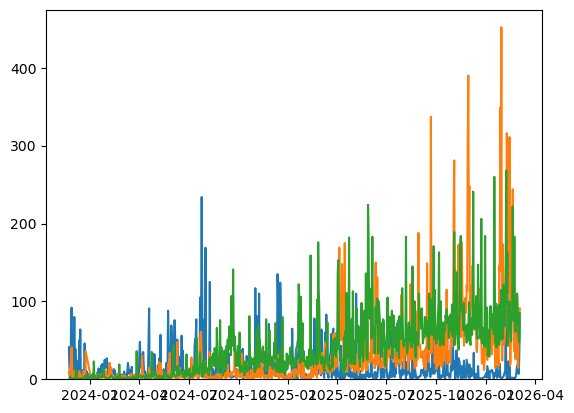

In [3]:
import matplotlib.pyplot as plt
data_filtered = {}

plt.figure()
for row in data.itertuples():
    print(row.label, row.data)
    xs = [point['x'] for point in row.data]
    ys = [point['y'] for point in row.data]
    print(len(xs), len(ys))
    # convert to datetime
    xs = [datetime.datetime.strptime(x, "%Y-%m-%d") for x in xs]
    plt.plot(xs, ys, label=row.label)
    data_filtered[row.label] = (xs, ys)

plt.ylim(bottom=0)

In [4]:
# make a new dataframe with Day as the index and "logged in", "anonymous", "crawlers" as columns

all_days = set()
for label, (xs, ys) in data_filtered.items():
    all_days.update(xs)

all_days = sorted(all_days)

df = pandas.DataFrame(columns=data_filtered.keys(), index=all_days)

for label, (xs, ys) in data_filtered.items():
    for x, y in zip(xs, ys):
        df.loc[x, label] = y

# set index name
df.index.name = "Day"

# convert index to column
df.reset_index(inplace=True)
df

,Day,Logged in users,Anonymous users,Crawlers
0,2023-11-23,41,9,NaN
1,2023-11-24,15,5,2
2,2023-11-26,1,18,NaN
3,2023-11-27,75,25,1
4,2023-11-28,92,41,1
...,...,...,...,...
823,2026-02-28,NaN,21,97
824,2026-03-01,NaN,15,70
825,2026-03-02,7,83,49
826,2026-03-03,28,72,47


In [ ]:
# group per month based on the "Day" index (sum numeric columns only)
df_monthly = df.groupby(
    df["Day"].dt.to_period("M")
)[["Logged in users", "Anonymous users", "Crawlers"]].sum()

df_monthly

,Logged in users,Anonymous users,Crawlers
Day,,,
2023-11,276,113,4
2023-12,474,124,41
2024-01,251,70,96
2024-02,242,92,58
2024-03,153,49,77
2024-04,537,159,138
2024-05,594,206,104
2024-06,640,190,278
2024-07,1078,347,380


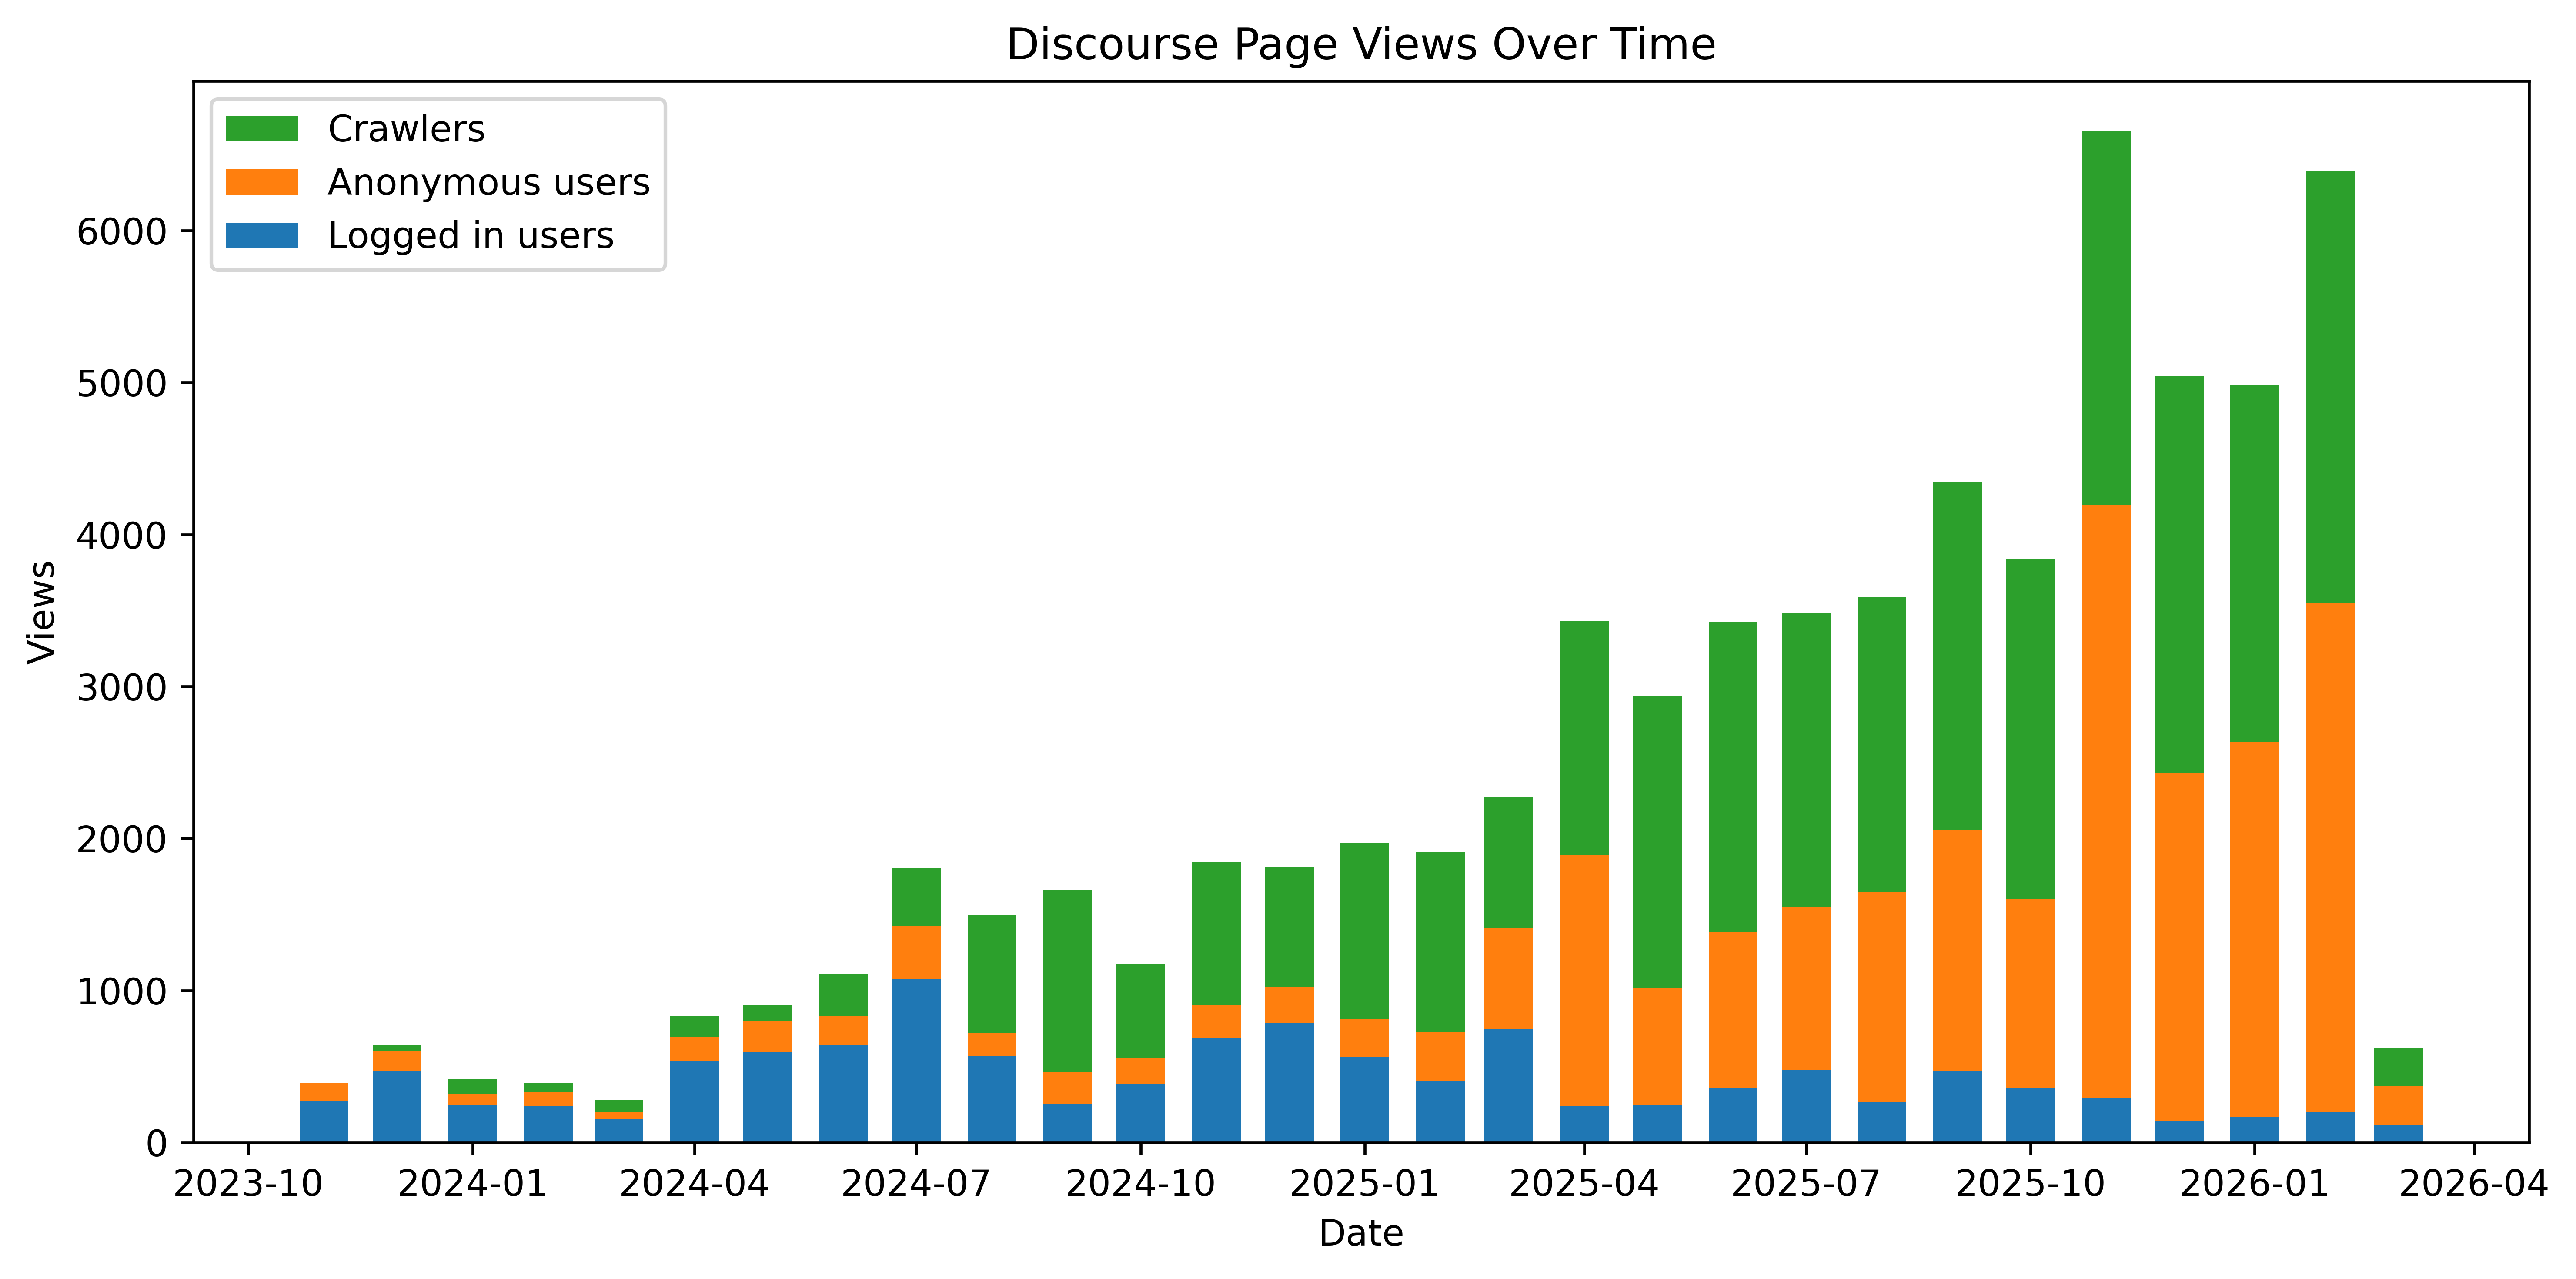

In [6]:
import matplotlib.pyplot as plt


def plot_page_views(width=20):
    x = (
        df_monthly.index.to_timestamp()
        if hasattr(df_monthly.index, "to_timestamp")
        else df_monthly.index
    )
    plt.bar(
        x,
        df_monthly["Logged in users"],
        label="Logged in users",
        width=width,
    )
    plt.bar(
        x,
        df_monthly["Anonymous users"],
        bottom=df_monthly["Logged in users"],
        label="Anonymous users",
        width=width,
    )
    plt.bar(
        x,
        df_monthly["Crawlers"],
        bottom=df_monthly["Logged in users"]
        + df_monthly["Anonymous users"],
        label="Crawlers",
        width=width,
    )


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_page_views(width=20)
plt.title("Discourse Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()